# Flight delays analysis
investigation the nature of flight delays in the United States.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

flights = pd.read_csv('../datasets/flights.csv', low_memory=False)
airports = pd.read_csv('../datasets/airports.csv', low_memory=False)
airlines = pd.read_csv('../datasets/airlines.csv', low_memory=False)

print(airlines.head())
print(airports.head())
print(flights.head())

  IATA_CODE                 AIRLINE
0        UA   United Air Lines Inc.
1        AA  American Airlines Inc.
2        US         US Airways Inc.
3        F9  Frontier Airlines Inc.
4        B6         JetBlue Airways
  IATA_CODE                              AIRPORT         CITY STATE COUNTRY  \
0       ABE  Lehigh Valley International Airport    Allentown    PA     USA   
1       ABI             Abilene Regional Airport      Abilene    TX     USA   
2       ABQ    Albuquerque International Sunport  Albuquerque    NM     USA   
3       ABR            Aberdeen Regional Airport     Aberdeen    SD     USA   
4       ABY   Southwest Georgia Regional Airport       Albany    GA     USA   

   LATITUDE  LONGITUDE  
0  40.65236  -75.44040  
1  32.41132  -99.68190  
2  35.04022 -106.60919  
3  45.44906  -98.42183  
4  31.53552  -84.19447  
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1   

## Data preparation
The dataset contains missing values primarily related to cancelled flights and delay categories. 

For delay analysis we exclude cancelled flights because they distort actual delay duration statistics.

In [22]:
print(flights.isna().sum().sort_values(ascending=False).head(20))

df = flights.copy()

df_delays = df[df["CANCELLED"] == 0]

df_delays = df_delays.dropna(
    subset=["DEPARTURE_DELAY", "ARRIVAL_DELAY"]
)

print('\n',df_delays.shape)

CANCELLATION_REASON    5729195
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
AIRLINE_DELAY          4755640
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
ELAPSED_TIME            105071
AIR_TIME                105071
ARRIVAL_DELAY           105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
WHEELS_OFF               89047
TAXI_OUT                 89047
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
DESTINATION_AIRPORT          0
DAY                          0
dtype: int64

 (5714008, 31)


## Question 1. Which days create the biggest traffic jam?

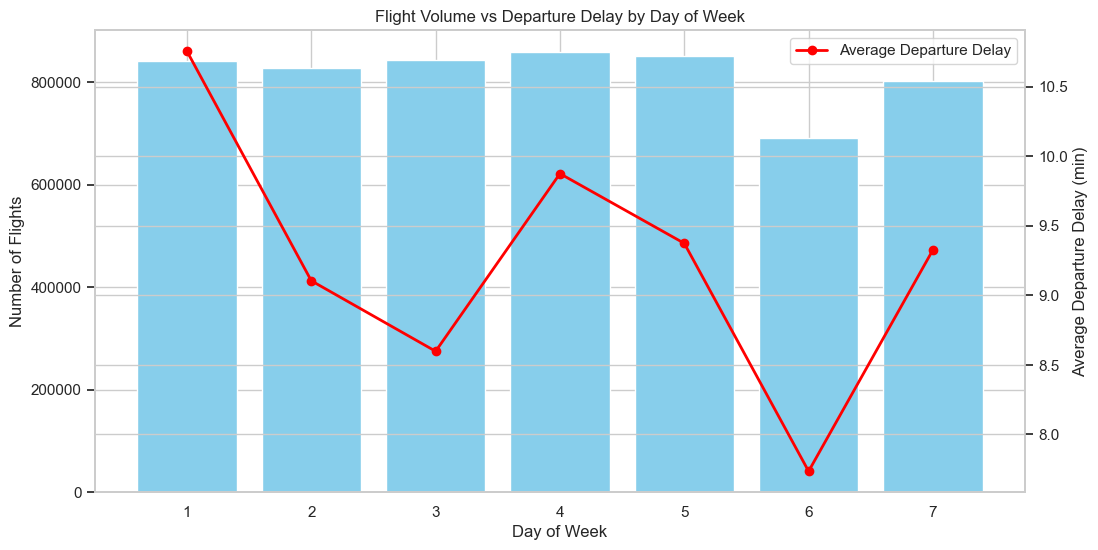

In [47]:
day_stats = df_delays.groupby("DAY_OF_WEEK").agg({
    "DEPARTURE_DELAY": "mean",
    "FLIGHT_NUMBER": "count"
}).rename(columns={
    "DEPARTURE_DELAY": "AVG_DELAY",
    "FLIGHT_NUMBER": "NUM_FLIGHTS"
})

fig, ax1 = plt.subplots(figsize=(12,6))

ax2 = ax1.twinx()

bars = ax1.bar(
    day_stats.index,
    day_stats["NUM_FLIGHTS"],
    color="skyblue",
    label="Number of Flights"
)

line = ax2.plot(
    day_stats.index,
    day_stats["AVG_DELAY"],
    marker="o",
    color="red",
    linewidth=2,
    label="Average Departure Delay"
)

ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Number of Flights")
ax2.set_ylabel("Average Departure Delay (min)")

plt.title("Flight Volume vs Departure Delay by Day of Week")
handles2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(
    handles2,
    labels2,
    loc="upper right"
)
plt.show()

The graph shows that increased traffic does not correlates with higher delays, however we can see, that sunday show the least average delay.

## Question 2. Which airports generate the largest delays?

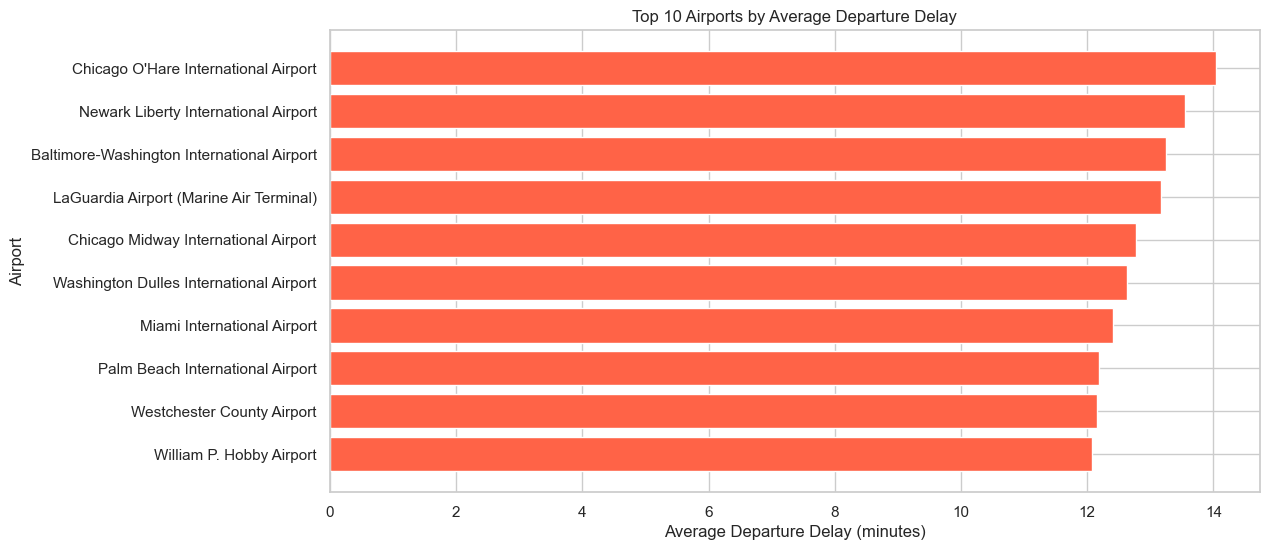

In [58]:
airport_delay = df_delays.groupby("ORIGIN_AIRPORT").agg({
    "DEPARTURE_DELAY": ["mean", "count"]
})

airport_delay.columns = ["AVG_DELAY", "NUM_FLIGHTS"]

airport_delay = airport_delay[
    airport_delay["NUM_FLIGHTS"] > 5000
]

top_airports = airport_delay.sort_values(
    "AVG_DELAY",
    ascending=False
).head(10)

top_airports = top_airports.merge(
    airports,
    left_index=True,
    right_on="IATA_CODE"
)

plt.figure(figsize=(12,6))

plt.barh(
    top_airports["AIRPORT"],
    top_airports["AVG_DELAY"],
    color="tomato"
)

plt.xlabel("Average Departure Delay (minutes)")
plt.ylabel("Airport")
plt.title("Top 10 Airports by Average Departure Delay")

plt.gca().invert_yaxis()

plt.show()

Chicago's, Newark's, Baltimor's airports show systematical higher delays than others.
This may indicate:
- overloaded runway infrastructure
- insufficient gate capacity
- inefficient scheduling
- or regional weather vulnerability

## Question 3. Are delays caused by airlines or airports?
We compare airlines by average delay and cancellation rate.

This helps determine whether operational management differs significantly between carriers.

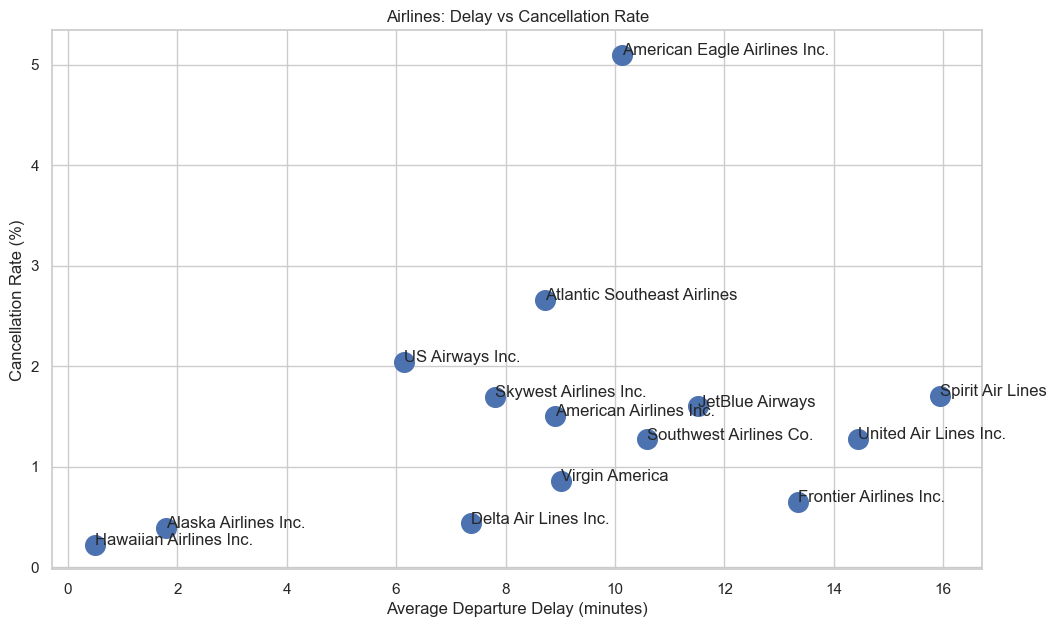

In [25]:
airline_stats = flights.groupby("AIRLINE").agg({
    "DEPARTURE_DELAY": "mean",
    "CANCELLED": "mean"
})

airline_stats.columns = [
    "AVG_DELAY",
    "CANCELLATION_RATE"
]

airline_stats = airline_stats.merge(
    airlines,
    left_index=True,
    right_on="IATA_CODE"
)

fig, ax = plt.subplots(figsize=(12,7))

scatter = ax.scatter(
    airline_stats["AVG_DELAY"],
    airline_stats["CANCELLATION_RATE"] * 100,
    s=200
)

for i, row in airline_stats.iterrows():
    ax.text(
        row["AVG_DELAY"],
        row["CANCELLATION_RATE"] * 100,
        row["AIRLINE"]
    )

plt.xlabel("Average Departure Delay (minutes)")
plt.ylabel("Cancellation Rate (%)")
plt.title("Airlines: Delay vs Cancellation Rate")
plt.show()

Airlines with high delays does not cancel flights frequently. Airlines manage with problems in different ways. That means, that airports should organise their flights better according to airlines's competence.

## Question 4. What is the main cause of delays?

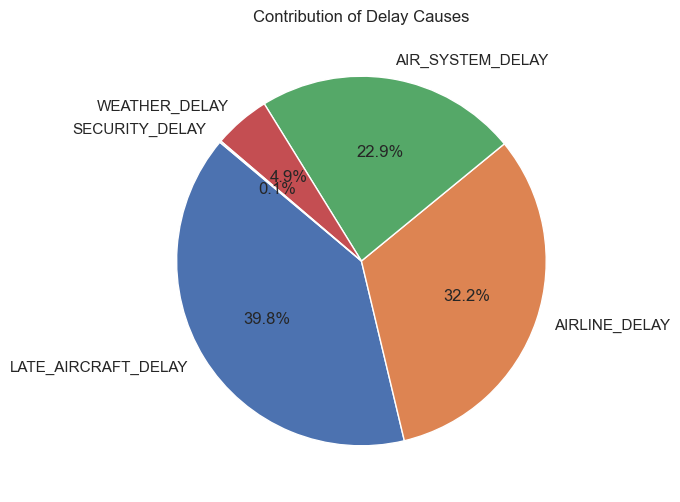

In [26]:
delay_causes = df_delays[[
    "AIRLINE_DELAY",
    "WEATHER_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY"
]].sum()

delay_causes = delay_causes.sort_values(ascending=False)

plt.pie(
    delay_causes,
    labels=delay_causes.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Contribution of Delay Causes")
plt.show()

This graph also proves conclusion from the last qustion. Late aircraft delay get the majority of delay's reasons.

## Question 5. Does airport traffic create delays?

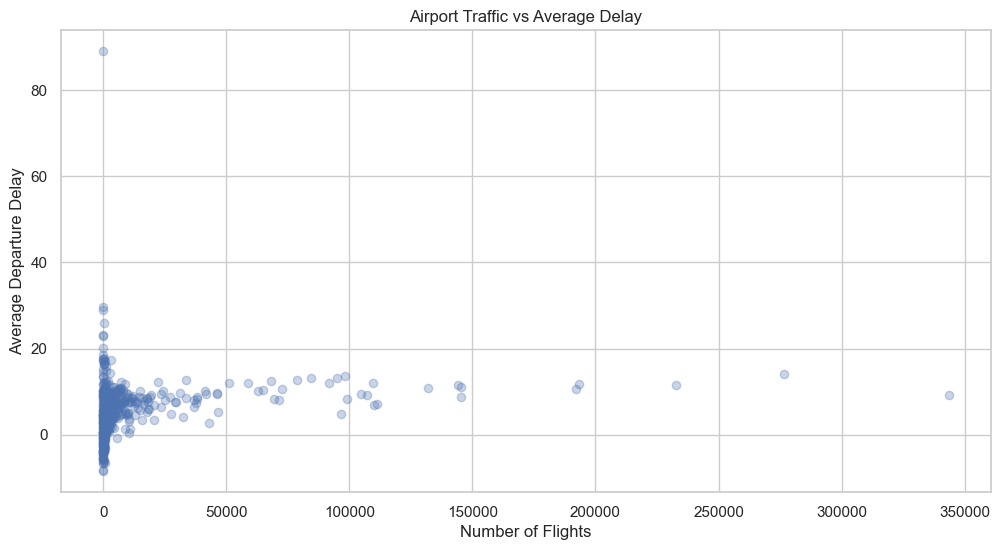

In [65]:
traffic_stats = df_delays.groupby("ORIGIN_AIRPORT").agg({
    "FLIGHT_NUMBER": "count",
    "DEPARTURE_DELAY": "mean"
})

traffic_stats.columns = [
    "NUM_FLIGHTS",
    "AVG_DELAY"
]

plt.scatter(
    data=traffic_stats,
    x="NUM_FLIGHTS",
    y="AVG_DELAY",
    alpha=0.3
)

plt.xlabel("Number of Flights")
plt.ylabel("Average Departure Delay")
plt.title("Airport Traffic vs Average Delay")
plt.show()

This graph show that there is no linear dependence between number of flights and delays. However accumulation of delays is observed among small airports.